# 02 — Forecasting

Build a simple daily sales forecasting model using LightGBM.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

In [2]:
from src.features.feature_engineering import build_features
from src.data.loader import load_data

raw = load_data(
    trans_path="../data/raw/transaction_data.csv",
    products_path="../data/raw/product.csv"
)


In [3]:
data, X, y, ids, encoders, feature_columns, num_cols,_ = build_features(raw)

data.head(10)


[RAW DATA]
  Shape: (2595732, 18)

[AGGREGATION]
  Shape: (1847974, 11)

[FULL DATE GRID]
  Shape: (92339, 11)

[CALENDAR FEATURES]
  Shape: (92339, 16)

[PROMOTION FEATURES]
  Shape: (92339, 19)
[LAGS] Created: lag_1, lag_7, lag_14, lag_28

[LAG FEATURES]
  Shape: (92339, 23)


KeyError: 'PRODUCT_ID'

In [16]:
print(data.shape)

data.info()

(27598, 19)
<class 'pandas.DataFrame'>
RangeIndex: 27598 entries, 0 to 27597
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   WEEK_NO             27598 non-null  int64  
 1   COMMODITY_DESC      27598 non-null  int64  
 2   QUANTITY            27598 non-null  int64  
 3   RETAIL_DISC         27598 non-null  float64
 4   COUPON_DISC         27598 non-null  float64
 5   DEPARTMENT          27598 non-null  int64  
 6   month               27598 non-null  int64  
 7   quarter             27598 non-null  int64  
 8   discount_amount     27598 non-null  float64
 9   has_discount        27598 non-null  int64  
 10  active_weeks        27598 non-null  int64  
 11  category_frequency  27598 non-null  float64
 12  lag_1               27598 non-null  float64
 13  lag_2               27598 non-null  float64
 14  lag_4               27598 non-null  float64
 15  lag_8               27598 non-null  float64
 16  rol

In [17]:
max_day = data["WEEK_NO"].max()

test_days = 4

split_day = max_day - test_days

train = data[data["WEEK_NO"] <= split_day].copy()
test = data[data["WEEK_NO"] > split_day].copy()

print(f"Train: {train.shape}")
print(f"Test : {test.shape}")

print(f"Train days: {train['WEEK_NO'].min()} - {train['WEEK_NO'].max()}")
print(f"Test days : {test['WEEK_NO'].min()} - {test['WEEK_NO'].max()}")

Train: (26498, 19)
Test : (1100, 19)
Train days: 1 - 98
Test days : 99 - 102


In [18]:
target = "QUANTITY"

drop_columns = [
    target
]

X_train = train.drop(
    columns=drop_columns
)

y_train = train[target]

X_test = test.drop(
    columns=drop_columns
)

y_test = test[target]

In [19]:
from lightgbm import LGBMRegressor, early_stopping, record_evaluation

evals_result = {}

model = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_test, y_test)
    ],
    eval_names=[
        "train",
        "test"
    ],
    eval_metric="rmse",
    callbacks=[
        record_evaluation(evals_result),
        early_stopping(50)
    ]
)

/home/mhseddighi/Projects/promotion-intelligence/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004456 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3038
[LightGBM] [Info] Number of data points in the train set: 26498, number of used features: 18
[LightGBM] [Info] Start training from score 9431.773455
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[91]	train's rmse: 18532.8	train's l2: 3.43463e+08	test's rmse: 7343.64	test's l2: 5.39291e+07


LGBMRegressor(learning_rate=0.03, n_estimators=700, n_jobs=-1, num_leaves=64,
              random_state=42)

In [22]:
pred = model.predict(X_test)

pred = np.maximum(pred, 0)

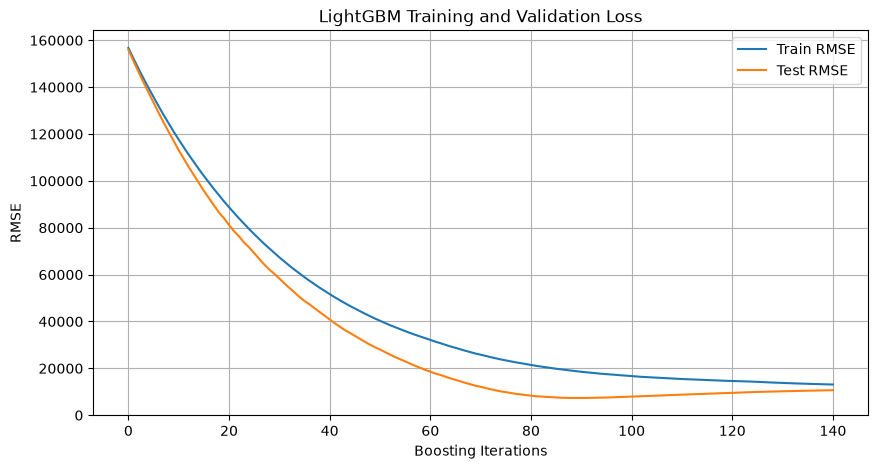

In [23]:
train_rmse = evals_result["train"]["rmse"]
test_rmse = evals_result["test"]["rmse"]

plt.figure(figsize=(10, 5))

plt.plot(
    train_rmse,
    label="Train RMSE"
)

plt.plot(
    test_rmse,
    label="Test RMSE"
)

plt.xlabel("Boosting Iterations")
plt.ylabel("RMSE")

plt.title(
    "LightGBM Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.show()

In [24]:
mae = mean_absolute_error(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

r2 = r2_score(
    y_test,
    pred
)

mape = mean_absolute_percentage_error(
    y_test,
    pred
) * 100

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAPE : {mape:.2f}%")
print(f"R2   : {r2:.4f}")

MAE  : 919.407
RMSE : 6551.867
MAPE : 1223517723820236800.00%
R2   : 0.9983


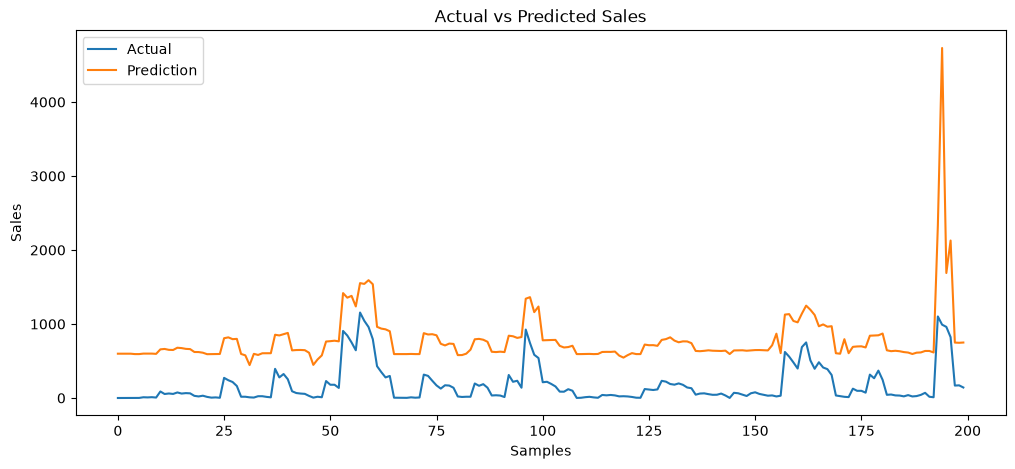

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:200],
    label="Actual"
)

plt.plot(
    pred[:200],
    label="Prediction"
)

plt.title(
    "Actual vs Predicted Sales"
)

plt.xlabel(
    "Samples"
)

plt.ylabel(
    "Sales"
)

plt.legend()

plt.show()

In [12]:
result = test[
    [
        "WEEK_NO",
        "SALES_VALUE"
    ]
].copy()

result["prediction"] = pred

weekly = result.groupby(
    "WEEK_NO"
).sum()

plt.figure(figsize=(12, 5))

plt.plot(
    weekly.index,
    weekly["SALES_VALUE"],
    marker="o",
    label="Actual"
)

plt.plot(
    weekly.index,
    weekly["prediction"],
    marker="o",
    label="Prediction"
)

plt.title(
    "Weekly Total Sales Forecast"
)

plt.xlabel(
    "Week"
)

plt.ylabel(
    "Sales"
)

plt.legend()

plt.show()

KeyError: "['SALES_VALUE'] not in index"

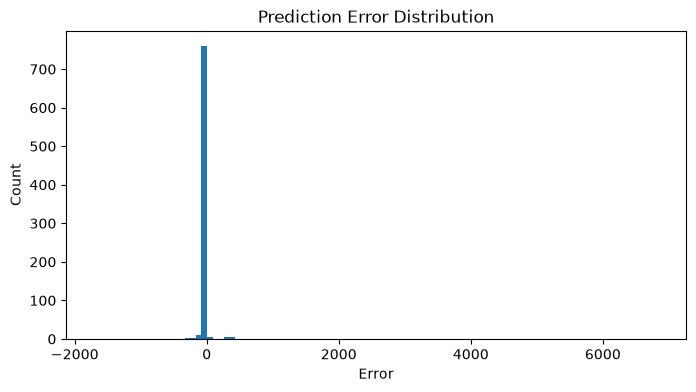

In [15]:
errors = y_test.values - pred

plt.figure(figsize=(8, 4))

plt.hist(
    errors,
    bins=100
)

plt.title(
    "Prediction Error Distribution"
)

plt.xlabel(
    "Error"
)

plt.ylabel(
    "Count"
)

plt.show()

In [16]:
importance = pd.DataFrame(
    {
        "feature": X_train.columns,
        "importance": model.feature_importances_
    }
)

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(20)

,feature,importance
17,avg_price,4223
4,SALES_VALUE,3946
5,RETAIL_DISC,1089
22,lag_28,1067
21,lag_14,905
19,lag_1,866
20,lag_7,601
0,DAY,404
2,STORE_ID,304
23,rolling_mean_7,246
